# Mastering Seaborn for AI/ML — Part 1
### Fundamentals → Datasets → Core Parameters → Relational, Distribution, Categorical & Regression Plots

This notebook is written for someone who already knows Python but is still building up
Data Science / ML intuition. The goal is not "here is a function, here is its output" —
the goal is: **why would a working ML engineer reach for this plot, and what decision
does it help them make?**



**Part 2** continues with Matrix plots, Pairwise/Facet/Joint grids, styling, the
statistics behind Seaborn, full EDA + ML workflows, model evaluation visualisation,
complete projects, interview prep and a cheat sheet.

> A honest note before you start: Seaborn is a *visualisation* library. It will help you
> understand your data and your model's behaviour, but a pretty plot is never proof that
> a model works. Keep that distinction in mind throughout — it comes up again in Part 2.


In [2]:
# Run this once if seaborn / pandas are not installed
# !pip install seaborn pandas matplotlib scikit-learn --quiet

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("seaborn:", sns.__version__)
print("pandas:", pd.__version__)


seaborn: 0.13.2
pandas: 2.2.3


## Part 1 — Seaborn Fundamentals

### What is Seaborn?
Seaborn is a Python data visualisation library built **on top of Matplotlib**. Matplotlib
gives you full control over every pixel of a figure, but that control comes at the cost of
writing a lot of code for common statistical plots. Seaborn wraps Matplotlib with
functions that understand **pandas DataFrames** and **statistical relationships**
directly, so a plot that would take 15–20 lines of Matplotlib often takes one line in
Seaborn.

### Why Seaborn exists
In a typical ML project you don't just want "a scatter plot" — you want "a scatter plot
of two features, coloured by class label, with a regression line per class." Doing that
in raw Matplotlib means manually looping over groups, picking colours, and building a
legend. Seaborn does all of that from a single function call because it understands the
*structure* of your data (which column is categorical, which is numeric, which is the
grouping variable).

### Seaborn vs Matplotlib
- **Matplotlib**: low-level, general-purpose plotting. You control everything, but you
  write more code. Best when you need a highly custom figure.
- **Seaborn**: high-level, statistics-aware. Less code, sensible defaults, built-in
  aggregation (means, confidence intervals) and DataFrame awareness. Best for fast,
  repeatable EDA (Exploratory Data Analysis).

In practice, professional workflows use **both**: Seaborn to generate the plot quickly,
Matplotlib to fine-tune titles, axis limits, saving to file, and combining multiple plots
into one figure.

### Seaborn vs Pandas plotting (`df.plot()`)
Pandas has a built-in `.plot()` method (itself a thin Matplotlib wrapper). It's fine for
a very quick look, but it has no concept of statistical aggregation, confidence
intervals, or elegant multi-variable grouping. Seaborn is the step up once you're doing
real EDA rather than a throwaway glance at your data.

### Seaborn architecture: Figure-level vs Axes-level functions
This is one of the most important structural ideas in Seaborn and trips up a lot of
beginners.

- **Axes-level functions** (e.g. `sns.scatterplot()`, `sns.boxplot()`, `sns.heatmap()`)
  draw onto a single Matplotlib `Axes` object. You can pass `ax=` to place them inside a
  subplot grid you built yourself. They return an `Axes`.
- **Figure-level functions** (e.g. `sns.relplot()`, `sns.catplot()`, `sns.displot()`,
  `sns.lmplot()`, `sns.pairplot()`, `sns.jointplot()`) manage their **own** Matplotlib
  Figure and can create multiple subplots automatically using `row=` / `col=` (this is
  called *faceting*). They return a `FacetGrid` / `PairGrid` / `JointGrid`, not an `Axes`.

Rule of thumb: if you need one plot embedded into a bigger custom layout → axes-level. If
you want Seaborn to automatically split your data into a grid of small multiples by
category → figure-level.

### `Figure` and `Axes` (the Matplotlib objects underneath)
Every plot lives inside a `Figure` (the whole image/canvas) which contains one or more
`Axes` (an individual plot area with its own x/y axis). When you call
`fig, ax = plt.subplots()`, `ax` is where an axes-level Seaborn function draws.


In [3]:
# Two typical imports at the top of almost every Seaborn notebook
import seaborn as sns
import matplotlib.pyplot as plt

# Why both, if Seaborn IS matplotlib underneath?
# - seaborn (sns) gives you the high-level statistical plotting functions
# - matplotlib.pyplot (plt) gives you fine control: titles, saving figures,
#   building custom subplot grids, adjusting layout, etc.
# In real projects you almost always need both.

sns.set_theme(style="whitegrid")  # sets a clean default look for every plot below


**Common mistake:** calling `sns.scatterplot()` and then trying to use `plt.subplot()`
tricks without understanding that some Seaborn functions (figure-level ones) already
create their own figure — mixing the two incorrectly produces empty extra figures.

**Practice task:** Import seaborn and matplotlib, set the theme to `"darkgrid"`, and print
the seaborn version. Then look up (via `dir(sns)`) five functions you don't recognise —
we will cover most of them in this notebook.


## Part 2 — Seaborn's Built-in Datasets

Seaborn ships with a small loader, `sns.load_dataset(name)`, that downloads well-known
teaching datasets (cached locally after first use). These are useful for **practice**,
not for your actual FYP/production dataset — but they're exactly what you should use in
this notebook to build muscle memory, and they mirror the *shape* of real ML datasets
(mixed numeric/categorical columns, missing values, imbalanced classes).

We'll focus on the ones that show up constantly in ML teaching material:

| Dataset | Rows | Represents | Good for practicing |
|---|---|---|---|
| `titanic` | ~891 | Passenger survival | Binary classification, mixed types, missing values |
| `tips` | 244 | Restaurant tips | Regression, categorical + numeric mix |
| `iris` | 150 | Flower measurements | Multi-class classification, clean data |
| `penguins` | ~344 | Penguin species/measurements | Classification, missing values |
| `flights` | 144 | Monthly passenger counts | Time series / line plots |
| `diamonds` | ~53,940 | Diamond price & attributes | Regression, large dataset, skewed target |
| `car_crashes` | 51 | US state crash statistics | Correlation / regression practice |
| `planets` | 1035 | Exoplanet discovery data | Skewed distributions, log scales |

Let's inspect one properly — this inspection routine (`head`, `info`, `describe`, `shape`,
`isnull().sum()`) should become automatic. You should run it on *every* dataset before you
plot anything, because a plot built on data you don't understand yet will mislead you.


In [4]:
titanic = sns.load_dataset("titanic")

titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.info()
# WHY this matters: tells you dtypes (object vs float vs category) and non-null counts.
# If a numeric-looking column shows up as 'object', that's a red flag — it likely has
# mixed types or stray strings that will break later processing.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
titanic.describe()
# WHY: gives mean/std/min/max/quartiles for numeric columns only.
# Look at min/max for anything suspicious (e.g. a negative age, or a fare of 0).


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
print("Shape:", titanic.shape)
print("\nColumns:", list(titanic.columns))
print("\nMissing values per column:\n", titanic.isnull().sum())


Shape: (891, 15)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Missing values per column:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


**Why do this before visualising?**
If you plot `age` without knowing ~20% of it is missing (as above), you might
misinterpret the distribution — Seaborn silently drops NaNs in most plots, which means
your chart quietly represents fewer rows than you think. Always check `isnull().sum()`
first so you know what fraction of data a plot is actually built on.

**Common mistake:** assuming a "clean-looking" built-in dataset means you can skip this
step. Titanic has real missing data (`age`, `deck`, `embarked`) on purpose — it's a
better teaching set *because* it's messy.

**Practice task:** Load `penguins` and `tips`. For each, print shape, dtypes, and missing
value counts. Which one is "cleaner"? Which columns would you call categorical vs
numeric vs target-like (i.e. what you'd try to predict)?


## Part 3 — Core Parameters You Will See Everywhere

These parameters appear across nearly every Seaborn function. Learning them once here
saves you from re-learning them in every section below.

| Parameter | Meaning | ML relevance |
|---|---|---|
| `data` | the DataFrame to plot from | always pass this — lets you reference columns by name string |
| `x`, `y` | column names for the axes | your feature(s) |
| `hue` | column used to colour points/bars by category | visualising how a **target class** or group affects a feature |
| `style` | column used to vary marker/line style | a second categorical grouping when colour alone isn't enough |
| `size` | column used to vary point/line size | showing a third numeric or categorical dimension |
| `palette` | which colour scheme to use | controlling readability / accessibility |
| `alpha` | point/fill transparency (0–1) | essential when you have overlapping points (dense data) |
| `bins` | number of histogram buckets | controls how coarse/fine a distribution looks |
| `kde` | whether to overlay a smooth density curve | seeing the "shape" of a distribution beyond a jagged histogram |
| `kind` | which sub-plot type a figure-level function should draw | e.g. `catplot(kind="box")` |
| `row`, `col` | column(s) used to split the plot into a grid (faceting) | comparing a relationship across categories side-by-side |
| `height`, `aspect` | size controls for figure-level plots | making faceted grids readable |
| `order`, `hue_order` | explicit ordering of categories | controlling category order instead of relying on default (often alphabetical/insertion) sorting |
| `estimator` | aggregation function (default: mean) | e.g. `estimator=np.median` when you suspect outliers skew the mean |
| `errorbar` | how to show uncertainty around an estimate | `"ci"` (confidence interval), `"sd"` (standard deviation), or `None` |

The parameter that most separates a "basic plot" from an "ML-useful plot" is **`hue`** —
almost every meaningful classification-EDA plot is really just
`sns.<something>(data=df, x=..., y=..., hue=target_column)`.


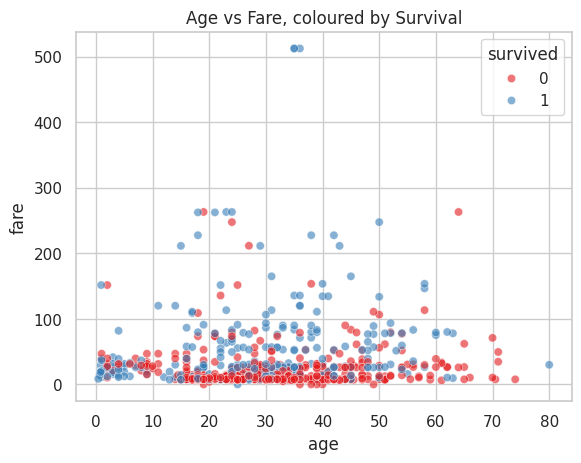

In [8]:
# A tiny demonstration of hue, alpha, and palette together
sns.scatterplot(
    data=titanic,
    x="age",
    y="fare",
    hue="survived",     # colour points by the target class
    alpha=0.6,           # helps when points overlap
    palette="Set1"
)
plt.title("Age vs Fare, coloured by Survival")
plt.show()


**When is this useful in ML/EDA?** This single line already tells you something:
higher fares cluster with more survivors, and most passengers (survivors or not) paid
low fares. That's a real signal worth investigating (fare likely correlates with class,
which historically correlated with access to lifeboats).

**Common mistake:** forgetting `data=` and instead passing raw arrays/Series for x and y
separately — it works, but you lose the ability to use `hue`/`style`/`size` by column
name, and your code becomes harder to reuse on a different DataFrame.


## Part 4 — Relational Plots (`scatterplot`, `lineplot`, `relplot`)

These answer the question: **"how does one variable relate to another?"** — the single
most common question in early-stage ML exploration.

### `sns.scatterplot()`
Shows individual data points on an x/y plane. This is your primary tool for:
- **Detecting correlation** between two numeric features (does one go up as the other does?)
- **Spotting clusters** (are there visually distinct groups?)
- **Finding outliers** (points far from the main cloud)
- **Checking linearity** — is the relationship a straight line, a curve, or no pattern at all?
- **Feature interactions** — using `hue`/`style`/`size` to bring in a 3rd–5th dimension


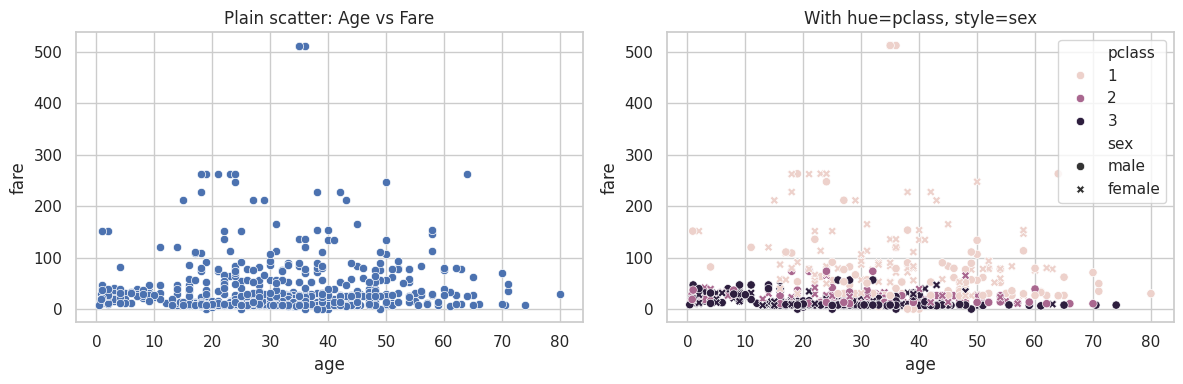

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=titanic, x="age", y="fare", ax=axes[0])
axes[0].set_title("Plain scatter: Age vs Fare")

sns.scatterplot(data=titanic, x="age", y="fare", hue="pclass", style="sex", ax=axes[1])
axes[1].set_title("With hue=pclass, style=sex")

plt.tight_layout()
plt.show()


Notice how the second plot, using the same two axes, reveals **class** (colour) and
**sex** (marker shape) simultaneously — this is the core value of `hue`/`style`: turning
a 2D plot into an effective 4D one without changing the axes.

### `sns.lineplot()`
Built for **ordered/continuous x-axes** — most commonly time. Two behaviours matter a lot
for ML:

1. **Automatic aggregation**: if multiple y-values exist for the same x (e.g. many
   observations per month), `lineplot()` plots the **mean** by default and shades a
   **confidence interval** around it — you don't have to `groupby()` manually.
2. **Multiple groups via `hue`**: perfect for comparing, e.g., training loss vs
   validation loss over epochs.

This is the plot you will use constantly once you start training models, for:
- Training loss / validation loss curves
- Accuracy over epochs
- Any time-series trend


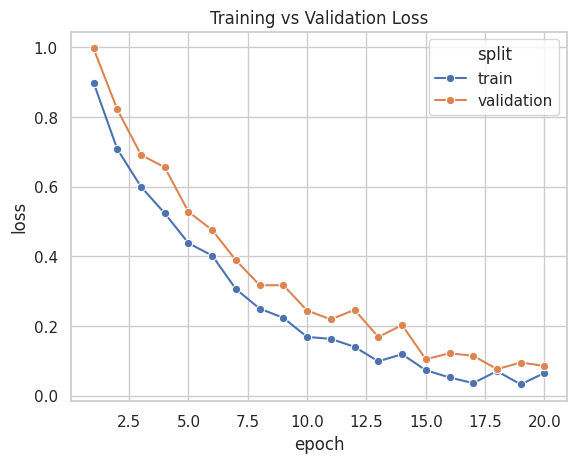

In [10]:
# Simulated training history — this is exactly how you'd plot a Keras/PyTorch
# training run's history object after converting it to a DataFrame.
epochs = np.arange(1, 21)
history = pd.DataFrame({
    "epoch": np.tile(epochs, 2),
    "loss": np.concatenate([
        1.0 * np.exp(-epochs / 6) + np.random.normal(0, 0.02, 20),   # train loss
        1.1 * np.exp(-epochs / 7) + np.random.normal(0, 0.03, 20)    # val loss
    ]),
    "split": ["train"] * 20 + ["validation"] * 20
})

sns.lineplot(data=history, x="epoch", y="loss", hue="split", marker="o")
plt.title("Training vs Validation Loss")
plt.show()


**Reading this plot correctly matters for your FYP report**: if validation loss starts
rising while training loss keeps falling, that's the classic visual signature of
**overfitting** — a concept you will need to discuss when you train your gesture
classification model in TensorFlow Lite.

### `sns.relplot()` — the figure-level version
`relplot(kind="scatter")` and `relplot(kind="line")` do what `scatterplot`/`lineplot` do,
but as a **figure-level** function — meaning you get `row=` / `col=` faceting for free.

Use `relplot()` instead of the axes-level versions specifically when you want Seaborn to
automatically generate a grid of small subplots split by a categorical column, rather
than manually looping and calling `plt.subplots()` yourself.


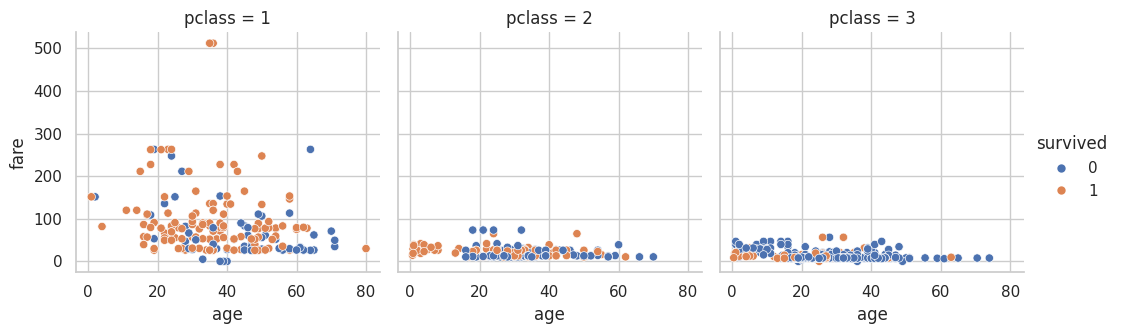

In [11]:
sns.relplot(
    data=titanic, x="age", y="fare",
    hue="survived", col="pclass",   # one subplot per passenger class
    height=3.5, aspect=1
)
plt.show()


**Common mistakes with relational plots:**
- Using a scatter plot for time-series data (use `lineplot` — scatter loses the ordering/trend).
- Treating a visible pattern in a scatter plot as *proof* of correlation — always confirm
  numerically (`df[[x, y]].corr()`) rather than eyeballing.
- Forgetting that `lineplot()`'s shaded region is a **confidence interval on the mean**,
  not the full spread of the raw data — don't mistake it for min/max range.

**Practice task:** Using `tips`, create a `relplot` with `x="total_bill"`, `y="tip"`,
`hue="time"`, `col="smoker"`. What do you notice about tipping behaviour on
smoking vs non-smoking tables?


## Part 5 — Distribution Visualisation

Understanding how a single feature is distributed is arguably **the single most
important EDA step before any ML model training** — it directly informs preprocessing
decisions (do you need a log transform? scaling? outlier removal?).

### `sns.histplot()` — Histograms
Splits a numeric range into `bins` and counts how many observations fall in each. Key
parameters:
- `bins` — number of buckets (too few hides structure, too many looks noisy)
- `stat` — `"count"` (default), `"density"`, `"probability"`, `"percent"` — matters when
  comparing groups of different sizes
- `kde=True` — overlays a smooth curve
- `hue` — compare distributions of one variable across categories
- `multiple` — `"layer"` (default overlap), `"stack"`, or `"dodge"` when using `hue`

Histograms reveal: **skewness**, **outliers**, **multi-modality** (more than one peak,
suggesting hidden subgroups), and — critically for classification — **class imbalance**
when plotting the target column.


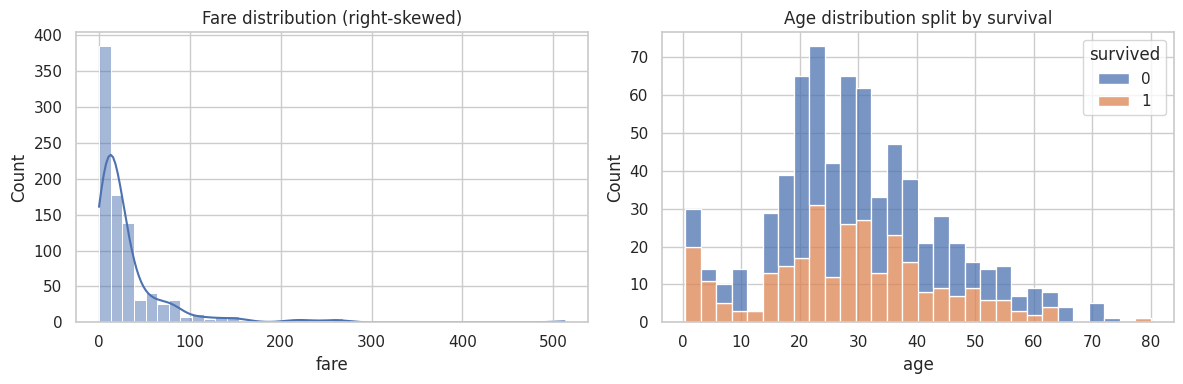

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=titanic, x="fare", bins=40, kde=True, ax=axes[0])
axes[0].set_title("Fare distribution (right-skewed)")

sns.histplot(data=titanic, x="age", hue="survived", multiple="stack", bins=30, ax=axes[1])
axes[1].set_title("Age distribution split by survival")

plt.tight_layout()
plt.show()


The `fare` histogram is a textbook **right-skewed** distribution — most passengers paid
little, a few paid a lot. In an ML pipeline this is exactly the kind of feature you'd
consider **log-transforming** before feeding into a linear model (tree-based models like
Random Forest/XGBoost are far less sensitive to this).

### `sns.kdeplot()` — Kernel Density Estimation
A KDE plot is a **smoothed, continuous estimate** of a distribution's probability
density, built by placing a small smooth "bump" (kernel) at every data point and summing
them. It solves histograms' main weakness — the shape changes depending on where bin
edges fall.

- `bw_adjust` — controls smoothing: higher = smoother/simpler curve, lower = more
  wiggly/detailed. Too high and you hide real structure (e.g. two overlapping classes
  looking like one blob); too low and you're just visualising noise.
- `fill=True` — shades under the curve
- `multiple="stack"` / `hue` — compare classes

**Important nuance**: KDE assumes the underlying distribution is smooth and continuous.
For a small dataset, or one with hard boundaries (e.g. a value that can never be
negative), KDE can show a curve that extends slightly past what's actually possible —
don't over-interpret the tails.


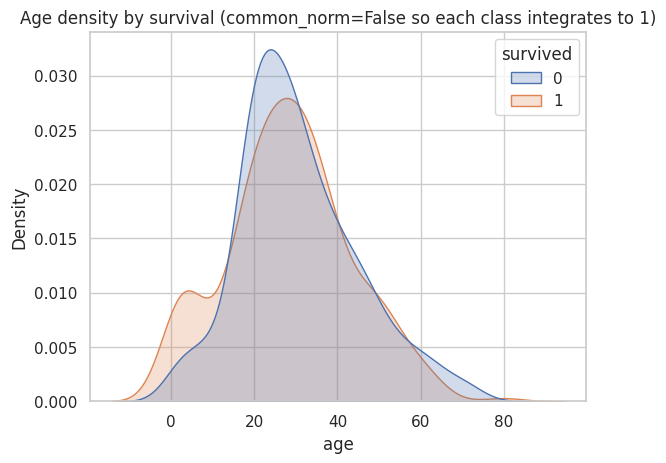

In [13]:
sns.kdeplot(data=titanic, x="age", hue="survived", fill=True, common_norm=False, bw_adjust=1)
plt.title("Age density by survival (common_norm=False so each class integrates to 1)")
plt.show()


`common_norm=False` is worth calling out: by default Seaborn normalises the *combined*
area of all groups to 1, which can make a minority class's curve look artificially flat.
Setting `common_norm=False` makes each group's curve independently sum to 1, so you're
comparing **shapes**, not raw counts — usually what you actually want in ML class
comparison.

### `sns.ecdfplot()` — Empirical Cumulative Distribution Function
Instead of showing density, an ECDF shows, for every value `v` on the x-axis, **what
fraction of the data is ≤ v**. It's less visually intuitive at first but has one big
advantage: **no binning, no smoothing parameter** — it shows the data exactly as it is,
with zero distortion. Use it when you want to make a precise, non-misleading claim like
"80% of passengers paid less than $X."

### `sns.rugplot()`
Draws a small tick mark on the axis for every single observation. Rarely used alone —
it's usually layered underneath a histogram or KDE (`sns.kdeplot(...); sns.rugplot(...)`)
to show the *exact* raw data points beneath a smoothed curve, which helps you judge
whether the smoothing is hiding sparse regions or outliers.

### `sns.displot()` — the figure-level distribution function
Wraps histogram, KDE, and ECDF behind one function via `kind="hist" | "kde" | "ecdf"`,
and adds `row=`/`col=` faceting.


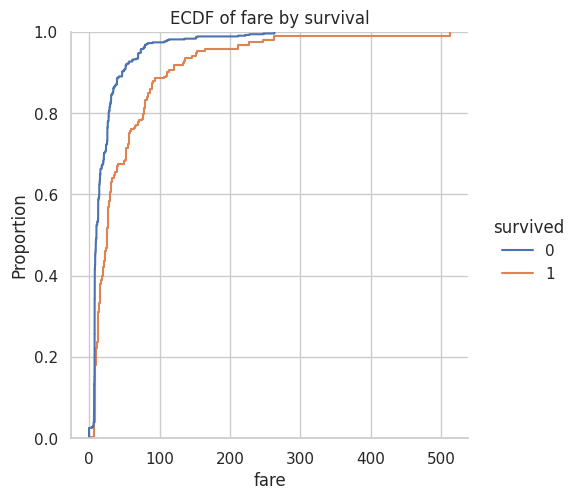

In [14]:
sns.displot(data=titanic, x="fare", hue="survived", kind="ecdf")
plt.title("ECDF of fare by survival")
plt.show()


**Common mistakes with distribution plots:**
- Picking a `bins` value and never questioning it — try 2–3 different values before
  deciding a histogram "shows" something real.
- Reading a KDE's peak height as "probability" — it's a density, not a probability; only
  the *area* under a region corresponds to probability mass.
- Comparing histograms of groups with very different sizes using raw counts instead of
  `stat="density"` — you'll wrongly conclude the bigger group has "more" of everything.

**Practice task:** For `penguins`, plot the distribution of `flipper_length_mm` split by
`species` using both `histplot` (`multiple="dodge"`) and `kdeplot`. Which species looks
most separable from the others just by this one feature? That's a strong candidate
feature for a classifier.


## Part 6 — Categorical Plots

These compare a numeric variable **across categories**, or summarise category
frequencies directly. This is where class-imbalance detection and per-class feature
comparison live — both essential before training a classifier.

### `sns.countplot()` — category frequencies
Counts how many rows fall into each category. The single fastest way to check for
**class imbalance** (a very common real-world classification problem — including sign
language gesture datasets, where some gestures will naturally be recorded far more than
others unless you deliberately balance collection).


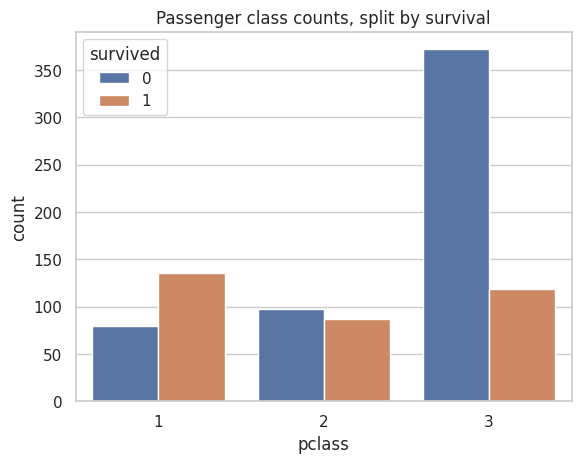

In [15]:
sns.countplot(data=titanic, x="pclass", hue="survived")
plt.title("Passenger class counts, split by survival")
plt.show()


### `sns.barplot()` — aggregated numeric value per category
Unlike `countplot` (which counts rows), `barplot` computes a **statistic** (mean, by
default) of a numeric column **within** each category, and adds an error bar showing
uncertainty around that estimate.

**`barplot()` vs `countplot()` — the distinction that confuses almost everyone at first:**
- `countplot(x="pclass")` → "how many rows have each `pclass` value?"
- `barplot(x="pclass", y="fare")` → "what is the *average fare* within each `pclass`?"

They look similar (both are bar charts) but answer completely different questions.


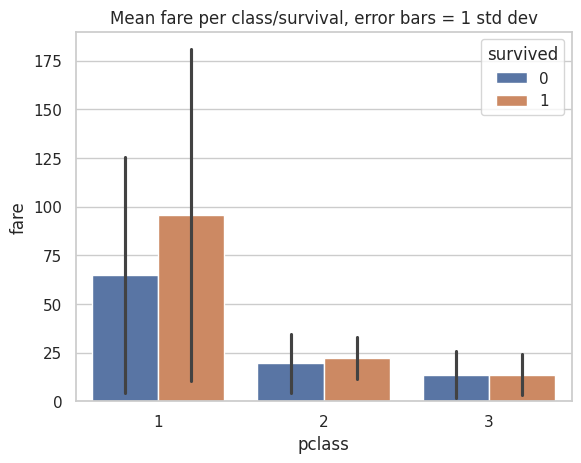

In [16]:
sns.barplot(data=titanic, x="pclass", y="fare", hue="survived", estimator=np.mean, errorbar="sd")
plt.title("Mean fare per class/survival, error bars = 1 std dev")
plt.show()


### `sns.boxplot()` — five-number summary per category
A box plot shows, per category: the **median** (middle line), **Q1/Q3** (box edges — the
25th/75th percentile), the **IQR** (interquartile range = Q3 − Q1, the box height), the
**whiskers** (typically 1.5×IQR beyond the box), and **outliers** as individual points
beyond the whiskers.

This is one of the most important plots for ML preprocessing because it directly shows
you: (1) how spread out a feature is per class, and (2) exactly which points would be
flagged as outliers under the standard 1.5×IQR rule — informing whether you clip, remove,
or transform them before training.


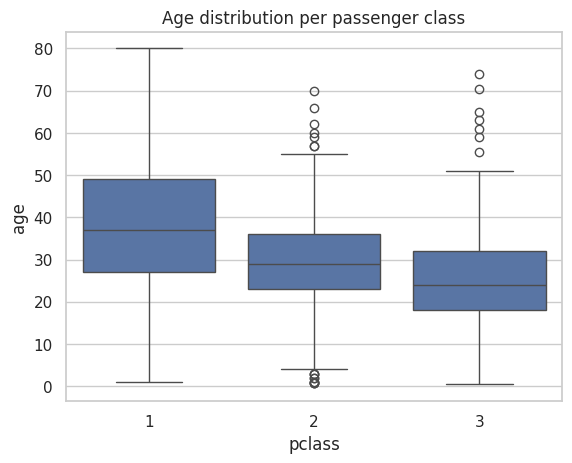

In [17]:
sns.boxplot(data=titanic, x="pclass", y="age")
plt.title("Age distribution per passenger class")
plt.show()


### `sns.violinplot()` — box plot + KDE combined
A violin plot is essentially a KDE mirrored on both sides, often with a mini box plot
drawn inside it. It gives you the five-number summary **and** the actual shape of the
distribution (is it one hump? two humps? skewed?) — information a plain box plot hides.
Use it when you suspect a category's distribution is **multi-modal** (has more than one
peak), which a box plot alone cannot show you.

### `sns.stripplot()` and `sns.swarmplot()` — individual points per category
- `stripplot`: plots every individual point, jittered horizontally so they don't all
  overlap on one vertical line.
- `swarmplot`: like `stripplot`, but arranges points so **none of them overlap** at all —
  more accurate, but computationally expensive and unreadable beyond a few hundred
  points ("overplotting" territory).

Use `swarmplot` for small/medium datasets when you want to see every actual data point
without any statistical summarising. Use `stripplot` when `swarmplot` becomes too slow
or crowded.

### `sns.pointplot()` — means connected by a line
Similar to `barplot` (shows mean + error bar per category) but draws a point and connects
categories with a line instead of bars — this makes **trends across ordered categories**
easier to see at a glance, and is very good for comparing multiple groups
(`hue`) without the visual clutter of many bars.


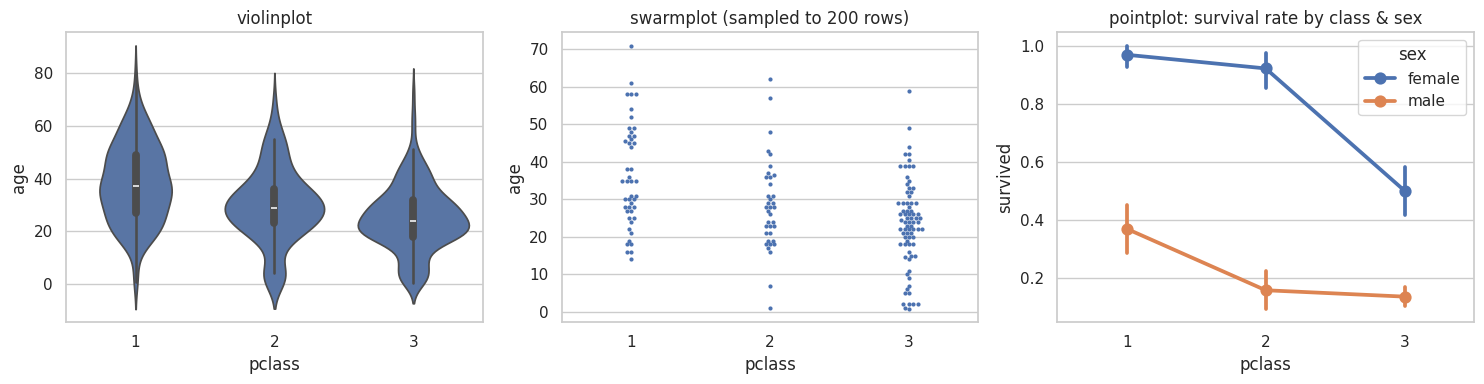

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.violinplot(data=titanic, x="pclass", y="age", ax=axes[0])
axes[0].set_title("violinplot")

sns.swarmplot(data=titanic.sample(200, random_state=1), x="pclass", y="age", ax=axes[1], size=3)
axes[1].set_title("swarmplot (sampled to 200 rows)")

sns.pointplot(data=titanic, x="pclass", y="survived", hue="sex", ax=axes[2])
axes[2].set_title("pointplot: survival rate by class & sex")

plt.tight_layout()
plt.show()


Notice the third plot: because `survived` is 0/1, its **mean** *is* the survival rate.
This single pointplot immediately shows the well-known Titanic pattern — women in 1st
class survived at far higher rates than men in 3rd class — without any manual
`groupby()`.

### `sns.catplot()` — the figure-level categorical function
Wraps all of the above behind `kind="strip" | "swarm" | "box" | "violin" | "bar" |
"point" | "count"`, with `row=`/`col=` faceting available, same as `relplot`.


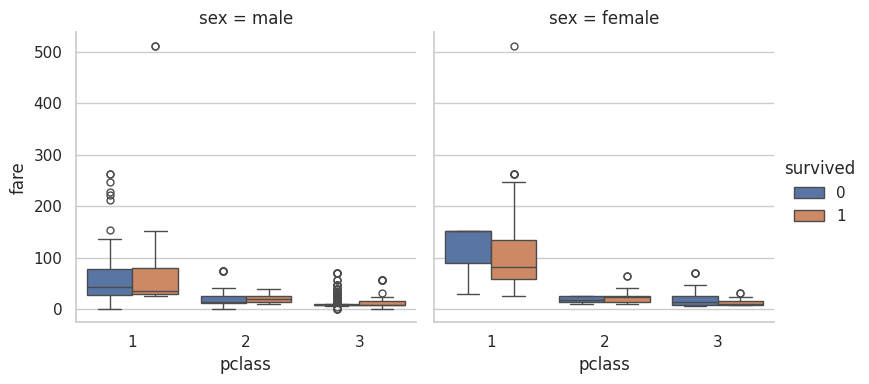

In [19]:
sns.catplot(data=titanic, x="pclass", y="fare", hue="survived", col="sex", kind="box", height=4)
plt.show()


**Common mistakes with categorical plots:**
- Using `barplot` when you actually meant `countplot` (or vice versa) — always ask
  yourself "am I counting rows, or averaging a numeric column?"
- Using `swarmplot` on a dataset with thousands of rows — it will be painfully slow and
  visually unreadable; sample the data first, as we did above.
- Not setting `order=` — Seaborn's default category ordering isn't always meaningful
  (e.g. alphabetical), which can make a chart harder to read than necessary.

**Practice task:** On `tips`, use `catplot(kind="violin")` with `x="day"`, `y="total_bill"`,
`hue="sex"`, `col="time"`. Which day/time combination has the widest spread of bill
amounts?


## Part 7 — Regression Visualisation

These plots overlay a **fitted line** on top of a scatter plot — useful for a quick visual
read on linear relationships, but (important distinction, expanded below) this is
**not** the same as training and validating a real regression model with scikit-learn.

### `sns.regplot()` — axes-level
Draws a scatter plot plus a fitted regression line with a shaded confidence interval
around it. Key parameters:
- `order=2` (or higher) — fits a polynomial instead of a straight line, useful when the
  relationship is visibly curved
- `logistic=True` — fits a logistic curve instead, appropriate when `y` is binary (0/1)
  rather than continuous
- `ci=None` — turn off the confidence band if it's cluttering the plot

### `sns.lmplot()` — figure-level
Same idea as `regplot`, but figure-level: supports `hue`, `row`, `col` to fit and compare
**separate regression lines per group**, and supports `lowess=True` for a flexible
non-parametric smoothing curve (good when you don't want to assume a specific functional
form).

**`regplot()` vs `lmplot()`**: use `regplot` when you want one regression line on an
existing axes (e.g. as part of a subplot grid you're building manually). Use `lmplot`
when you want Seaborn to automatically fit and compare multiple regression lines across
categories.


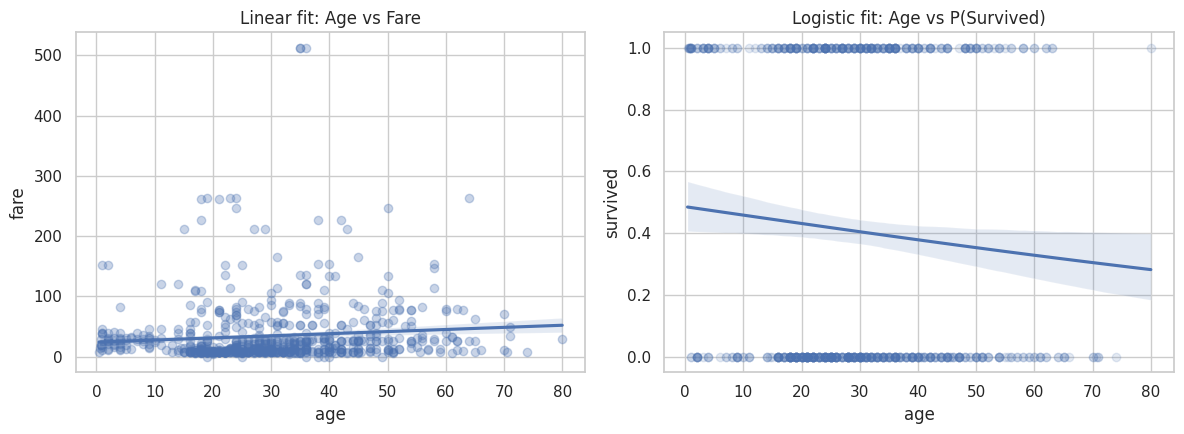

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.regplot(data=titanic, x="age", y="fare", scatter_kws={"alpha": 0.3}, ax=axes[0])
axes[0].set_title("Linear fit: Age vs Fare")

sns.regplot(data=titanic, x="age", y="survived", logistic=True,
            scatter_kws={"alpha": 0.15}, ax=axes[1])
axes[1].set_title("Logistic fit: Age vs P(Survived)")

plt.tight_layout()
plt.show()


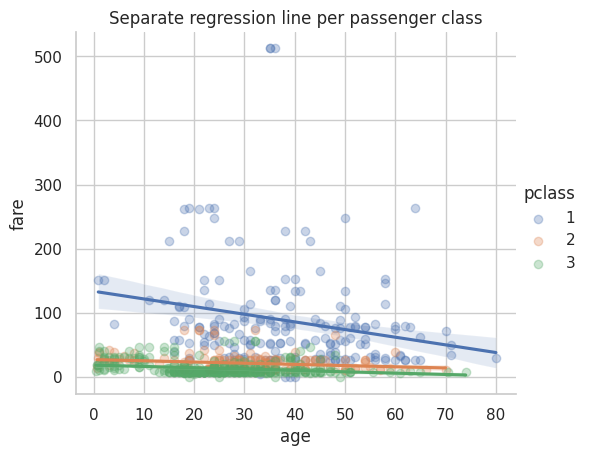

In [21]:
sns.lmplot(data=titanic, x="age", y="fare", hue="pclass", height=4.5, aspect=1.2,
           scatter_kws={"alpha": 0.3})
plt.title("Separate regression line per passenger class")
plt.show()




**Common mistakes:**
- Fitting a straight line (`regplot` default) to an obviously curved relationship without
  checking — always look at the raw scatter first.
- Using `logistic=True` on a continuous (non-binary) `y` — it will simply fail or give a
  nonsensical fit.
- Presenting an `lmplot` confidence band as if it were a prediction interval for new data
  — it's a confidence interval around the fitted line itself, not around future
  predictions.

**Practice task:** On `tips`, compare `regplot(x="total_bill", y="tip")` with
`order=1` vs `order=2`. Does a curved fit actually explain the data meaningfully better,
or is a straight line already reasonable? (This is the same judgement call you'll make
constantly during real feature-relationship exploration.)


---
### End of Part 1

You've now covered: Seaborn fundamentals & architecture, working with built-in datasets
correctly, the core parameters shared across the whole library, and the three biggest
plot families for early EDA — relational, distributional, and categorical — plus
regression visualisation and its limits.

**Continue in Part 2** for: Matrix plots (heatmaps, correlation, confusion matrices),
Pairwise/Facet/Joint grids, styling & colour systems, the statistics underneath Seaborn,
Seaborn + Pandas/NumPy/Matplotlib integration, a full EDA workflow, ML model evaluation
visualisation, feature engineering guidance, common mistakes, best practices, complete
projects, interview questions, and a final cheat sheet.
